int32
uint8


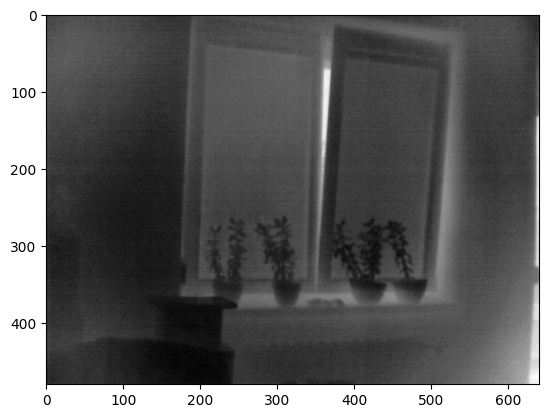

In [35]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import weompy

wimage = weompy.Image.load("test.wti")

image = np.array(wimage.getData()).reshape(wimage.getHeight(), wimage.getWidth())

nimage = cv.normalize(image, None, 0, 255, cv.NORM_MINMAX)
print(nimage.dtype)
nimage = nimage.astype(np.uint8)
print(nimage.dtype)

plt.imshow(nimage, cmap="Greys")

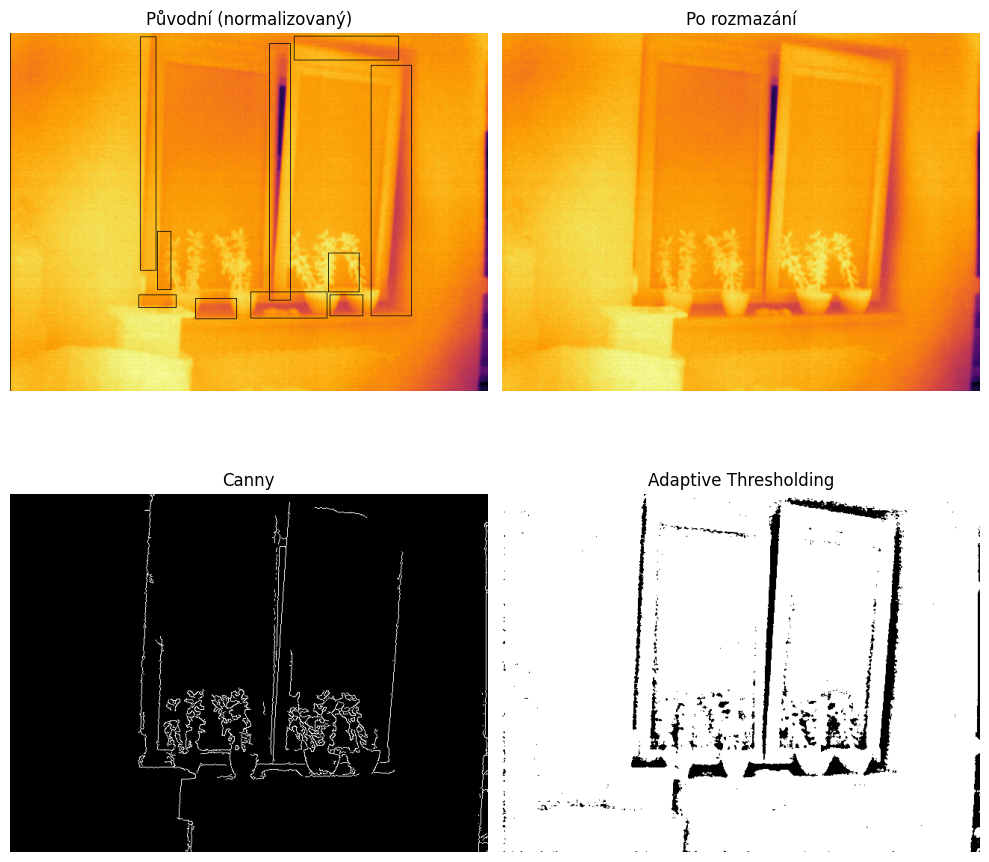

In [62]:
blurred = cv.GaussianBlur(nimage, (3, 3), 0.1, 0.1)
kernel = np.ones((3, 3), np.uint8)
morph = cv.morphologyEx(blurred, cv.MORPH_OPEN, kernel)

canny = cv.Canny(
    blurred,
    threshold1=20,
    threshold2=80
)

thresh = cv.adaptiveThreshold(
    blurred,
    maxValue=255,
    adaptiveMethod=cv.ADAPTIVE_THRESH_GAUSSIAN_C,
    thresholdType=cv.THRESH_BINARY,
    blockSize=55,
    C=8,
)
nimage_ = nimage.copy()
contours, _ = cv.findContours(thresh, cv.RETR_CCOMP, cv.CHAIN_APPROX_SIMPLE)


from sklearn.cluster import DBSCAN
areas = np.array([cv.contourArea(cnt) for cnt in contours]).reshape(-1, 1)
db = DBSCAN(eps=100, min_samples=5).fit(areas)
labels = db.labels_.astype(np.int8)

res = [contours[i] for i, m in enumerate(labels) if m == -1]

for cnt in res:
    x, y, w, h = cv.boundingRect(cnt)
    
    cv.rectangle(nimage_, (x, y), (x + w, y + h), (0, 255, 255), 1)


plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.title("Původní (normalizovaný)")
plt.imshow(nimage_, cmap="inferno")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Po rozmazání")
plt.imshow(blurred, cmap="inferno")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("Canny")
plt.imshow(canny, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("Adaptive Thresholding")
plt.imshow(thresh, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()